# Monte Carlo Simulation

Monte Carlo simulation provides a distribution of potential future outcomes, rather than just historical data points. This empowers decision-making by allowing us to look beyond past events and explore a wide range of hypothetical scenarios.

It's a computational technique using random sampling to model probabilities in processes difficult to predict due to random variables. Instead of fixed values, Monte Carlo generates thousands of random samples based on defined probability distributions.

Why is it valuable for decision-making, especially in finance and risk analysis?

* Forward-Looking: It projects future possibilities, offering a robust view of what could happen.

* Risk Quantification: It helps estimate the likelihood of extreme events (both positive and negative), crucial for understanding true investment risk.

* Flexibility: We can adjust variable distributions (like stock daily returns) to reflect different assumptions, volatility, or expected returns, and even isolate outlier impacts.

* Scenario Analysis: It facilitates exploring a vast universe of possible scenarios, from probable to improbable, providing a more complete understanding of potential outcomes.

By applying Monte Carlo simulation, we gain a clearer, more nuanced picture of potential risk and return, aiding more informed investment decisions and a better grasp of inherent market uncertainty.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In the following cell, we set up the initial conditions for our Monte Carlo simulation. Let's think of it as telling the simulation where to start and what kind of behavior to expect. The initial values came from the Simple_VaR_Analysis notebook.

In [8]:
initial_price = 4.0 
mean_daily_return = 0.0028 
std_daily_return = 0.0841  # Usa df['profit'].std() si tu df es el original


# Monte Carlo parameters
num_simulations = 10000 # Number of trajectories
num_trading_days = 252 # Days in one year
final_prices = []
# Store the first 100 trajectories.
simulated_paths = np.zeros((num_trading_days, 100))

print(f"Running Monte Carlo simulation for GN stock...")
print(f"  Initial Price: {initial_price}")
print(f"  Mean Daily Return: {mean_daily_return:.4f}")
print(f"  Std Dev Daily Return: {std_daily_return:.4f}")
print(f"  Number of Simulations: {num_simulations}")
print(f"  Trading Days (Horizon): {num_trading_days}")





Running Monte Carlo simulation for GN stock...
  Initial Price: 4.0
  Mean Daily Return: 0.0028
  Std Dev Daily Return: 0.0841
  Number of Simulations: 10000
  Trading Days (Horizon): 252


In the next cell, we generate random daily returns, drawing from what's called a normal distribution. Now, this assumes that our returns generally follow that typical bell-curve shape. For a bit more realism, especially in finance, we might actually want to use distributions with 'fatter tails' – meaning they're better at capturing those more extreme, less frequent gains or losses.

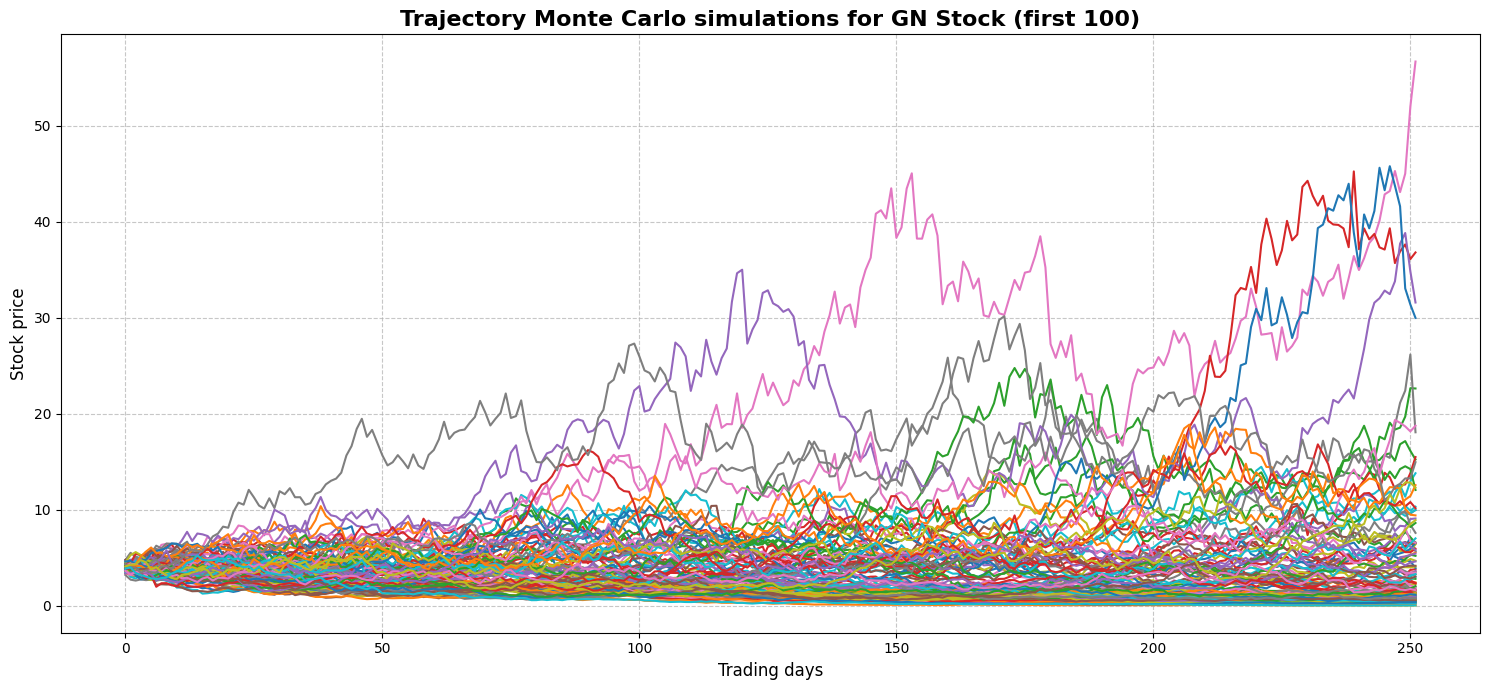

In [18]:
np.random.seed(3)

for i in range(num_simulations):
    # Normal simulation
    daily_returns = (
        np.random.normal(
            mean_daily_return, 
            std_daily_return, 
            num_trading_days)
    )

    # Prices trajectory
    price_path = [initial_price]

    # (1 + r) is used in financial calculations to update a price. 
    # This formula efficiently combines the previous day's price with 
    # a daily percentage return (r) to directly yield the new price.
    for r in daily_returns:
        price_path.append(price_path[-1] * (1 + r))

    final_prices.append(price_path[-1])

    # Fist 100 trajectories
    if i < 100:
        simulated_paths[:, i] = price_path[1:]



plt.figure(figsize=(15, 7))
plt.plot(simulated_paths)
plt.title('Trajectory Monte Carlo simulations for GN Stock (first 100)', fontsize=16, fontweight='bold')
plt.xlabel('Trading days', fontsize=12)
plt.ylabel('Stock price', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

The previous plot is a visualization of 100 simulated price paths for GN Stock over 250 trading days, generated using a Monte Carlo simulation. This type of graph is fundamental for understanding the possible future evolution of a financial asset under a set of assumptions regarding its returns and volatility.

## Key Observations and Implications for GN Stock:

1. Consistent Starting Point: All simulations kick off from a similar initial price (around $4-$5, which lines up with the "normal" GN stock price you mentioned before that big outlier spike).

2. Wide Dispersion of Outcomes: As time rolls on (heading towards day 250), the spread of these paths gets dramatically wider. This tells us there's a really high level of uncertainty about where GN Stock's price will land in the future. While some paths stick to a lower price range (near the starting value or even below), others shoot up to extremely high values (hitting $40 or even $50!).

3. Confirmation of High Volatility and Extreme Events:

    * The fact that some paths show significant vertical jumps (much like that historical outlier we spotted in your real data) confirms our simulation model (even with that outlier baked into its historical standard deviation) can indeed generate scenarios with very sudden price movements.

    * This visual just reinforces our conclusion that GN Stock is an asset with inherently high volatility. Even if that historical outlier was a one-off event, the underlying nature of the return distribution (which allowed it to happen) suggests that the potential for such extreme moves is always there.

4. Asymmetry in the Paths: There seems to be a noticeable asymmetry here; while some paths climb dramatically, the "floor" of the paths doesn't drop to extremely negative values in this specific chart (the Y-axis range focuses more on the highs). This could suggest that, although there's a big potential for losses (as your previous VaR figures indicated), the risk of the price completely collapsing might not be the dominant feature in most of the simulations visible within this range.



Let's plot the histogram

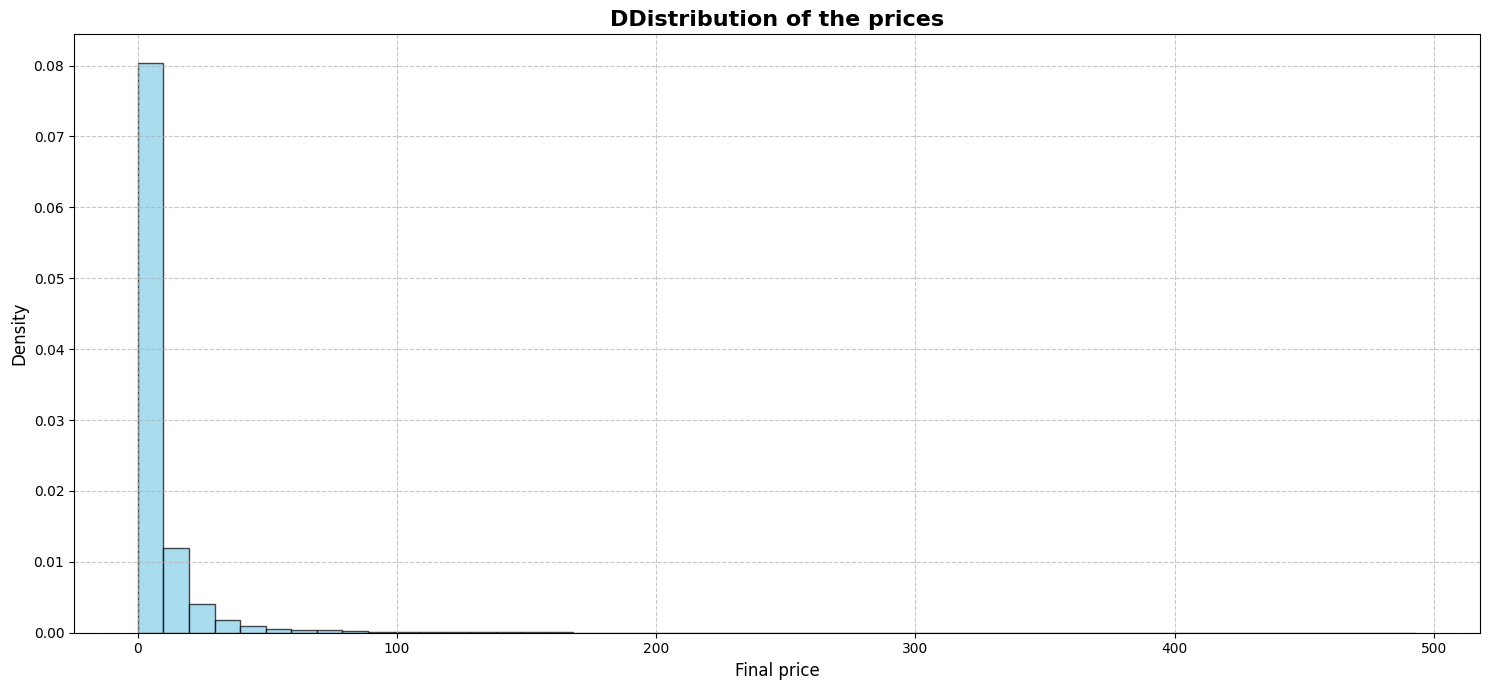

In [19]:
plt.figure(figsize=(15, 7))
plt.hist(final_prices, bins=50, density=True, alpha=0.7, color='skyblue', edgecolor='black')
plt.title('DDistribution of the prices', fontsize=16, fontweight='bold')
plt.xlabel('Final price', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

Looking at this histogram of GN Stock's simulated final prices, it tells a pretty clear story:

* Most Paths Lead to Little Gain (or Loss): The biggest takeaway is that the vast majority of our simulations end up with the stock price staying quite low, very close to where it started, or even indicating a loss. That huge, tall bar on the left really highlights that most scenarios aren't leading to big wins.

* Lottery Ticket Potential: Now, there is a long, thin tail stretching way out to the right. This represents those extremely rare instances where the stock price absolutely skyrockets (we're talking hundreds of dollars!). It's like finding that one winning lottery ticket – it's possible, but it's certainly not the most common outcome.

* It's a "Home Run or Bust" Play: This distribution is highly skewed, meaning while a few simulations hit it big, the overwhelming likelihood is a very modest return or even a loss. If you're looking for consistent, steady growth, this chart suggests GN Stock isn't it. This stock looks more like a high-risk, "all-or-nothing" bet, where you're really hoping to catch one of those super rare, massive spikes. You'd need to be comfortable with the strong probability of much smaller returns (or losses) while waiting for that long-shot big win.

# Key computations

In [22]:
simulated_prices_series = pd.Series(final_prices)

simulated_VaR_95_price = simulated_prices_series.quantile(0.05)

simulated_VaR_99_price = simulated_prices_series.quantile(0.01)

mean_final_price = simulated_prices_series.mean()

std_final_price = simulated_prices_series.std()

simulated_returns = (simulated_prices_series - initial_price) / initial_price
simulated_VaR_95_return = simulated_returns.quantile(0.05)
simulated_VaR_99_return = simulated_returns.quantile(0.01)


print("\n--- Simulation Results ---")
print(f"Initial Price: {initial_price:.2f}")
print(f"Average Simulated Final Price: {mean_final_price:.2f}")
print(f"Standard Deviation of Simulated Final Prices: {std_final_price:.2f}")
print(f"VaR_95 (Minimum price with 95% confidence): {simulated_VaR_95_price:.2f}")
print(f"VaR_99 (Minimum price with 99% confidence): {simulated_VaR_99_price:.2f}")
print(f"VaR_95 (Potential percentage loss with 95% confidence): {simulated_VaR_95_return:.2%}")
print(f"VaR_99 (Potential percentage loss with 99% confidence): {simulated_VaR_99_return:.2%}")



--- Simulation Results ---
Initial Price: 4.00
Average Simulated Final Price: 8.16
Standard Deviation of Simulated Final Prices: 17.45
VaR_95 (Minimum price with 95% confidence): 0.37
VaR_99 (Minimum price with 99% confidence): 0.15
VaR_95 (Potential percentage loss with 95% confidence): -90.79%
VaR_99 (Potential percentage loss with 99% confidence): -96.29%


# Conclusion from simulation results: 

## What do the numbers Tell us?

Alright, let's tie all of this together with the hard numbers from our Monte Carlo simulation, because they really paint a vivid picture.

We started with an Initial Price of \\$4.00. After running thousands of possible future scenarios, the average simulated final price comes out to \\$8.16. On the surface, that looks pretty good – a potential doubling of your money on average!

However, the SD of simulated final prices is a whopping \\$17.45. This number is absolutely massive compared to our average final price. What it screams is extreme volatility in the outcomes. While the average might be \\$8.16, the actual results are all over the map, from tiny gains to massive losses or even huge gains. This confirms what the "home run or bust" histogram was hinting at.

Now, let's talk about the downside, and this is where things get really serious:

Our VaR_95 (minimum price with 95% confidence) is a mere $0.37. This means that in 5% of our simulated futures (that's 1 out of every 20), the stock could end up being worth only 37 cents or even less.

And for VaR_99 (minimum price with 99% confidence), it drops to just \\$0.15. This is even more alarming; in $1%$ of the scenarios (1 out of every 100), you could see your $4.00 investment reduced to just 15 cents or less.

When we look at this as potential percentage loss, it's even starker:

The VaR_95 (potential percentage loss with 95% confidence) is -90.79%. Yes, you read that right. In 5% of the cases, you could lose over 90% of your initial investment.

And the VaR_99 (potential percentage loss with 99% confidence) is a devastating -96.29%. This means there's a 1% chance you could virtually lose your entire investment.

So, what's my conclusion?

This GN Stock, based on our Monte Carlo simulation, is incredibly high-risk, high-reward, but with a heavily skewed risk profile. While the average outcome suggests a nice gain, that average is heavily influenced by those very few "lottery ticket" scenarios where the stock explodes. For the vast majority of cases, you're looking at a much more modest, or frankly, devastating outcome.

It's essentially a speculative gamble. If you're an investor who can stomach losing almost your entire investment for a small chance at a massive gain, then maybe it fits your extreme risk tolerance. But for anyone seeking even a semblance of capital preservation or consistent growth, these numbers are a loud warning. You'd be putting a lot on the line for what is, for most outcomes, a very poor return or a massive loss. Be extremely cautious.